In [1]:
### CANCER DATASET - LoR MODEL

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

### 1. Load Cancer Dataset

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

df = X.copy()
df["target"] = y

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum().sum())

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \


### 2. Data Distribution


Target/Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

Target/Class Percentage:
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


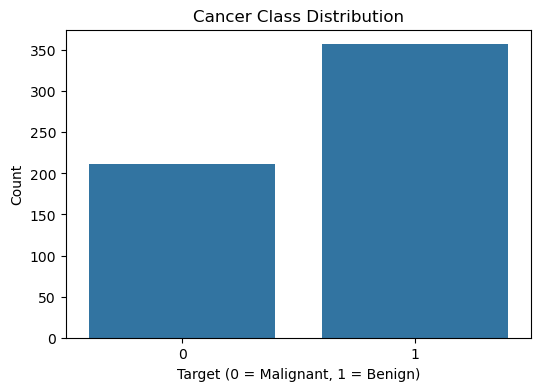

In [4]:
print("\nTarget/Class Distribution:")
print(df["target"].value_counts())

print("\nTarget/Class Percentage:")
print(df["target"].value_counts(normalize=True) * 100)

# Class distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df)
plt.title("Cancer Class Distribution")
plt.xlabel("Target (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")
plt.show()


### 3. Feature Distribution

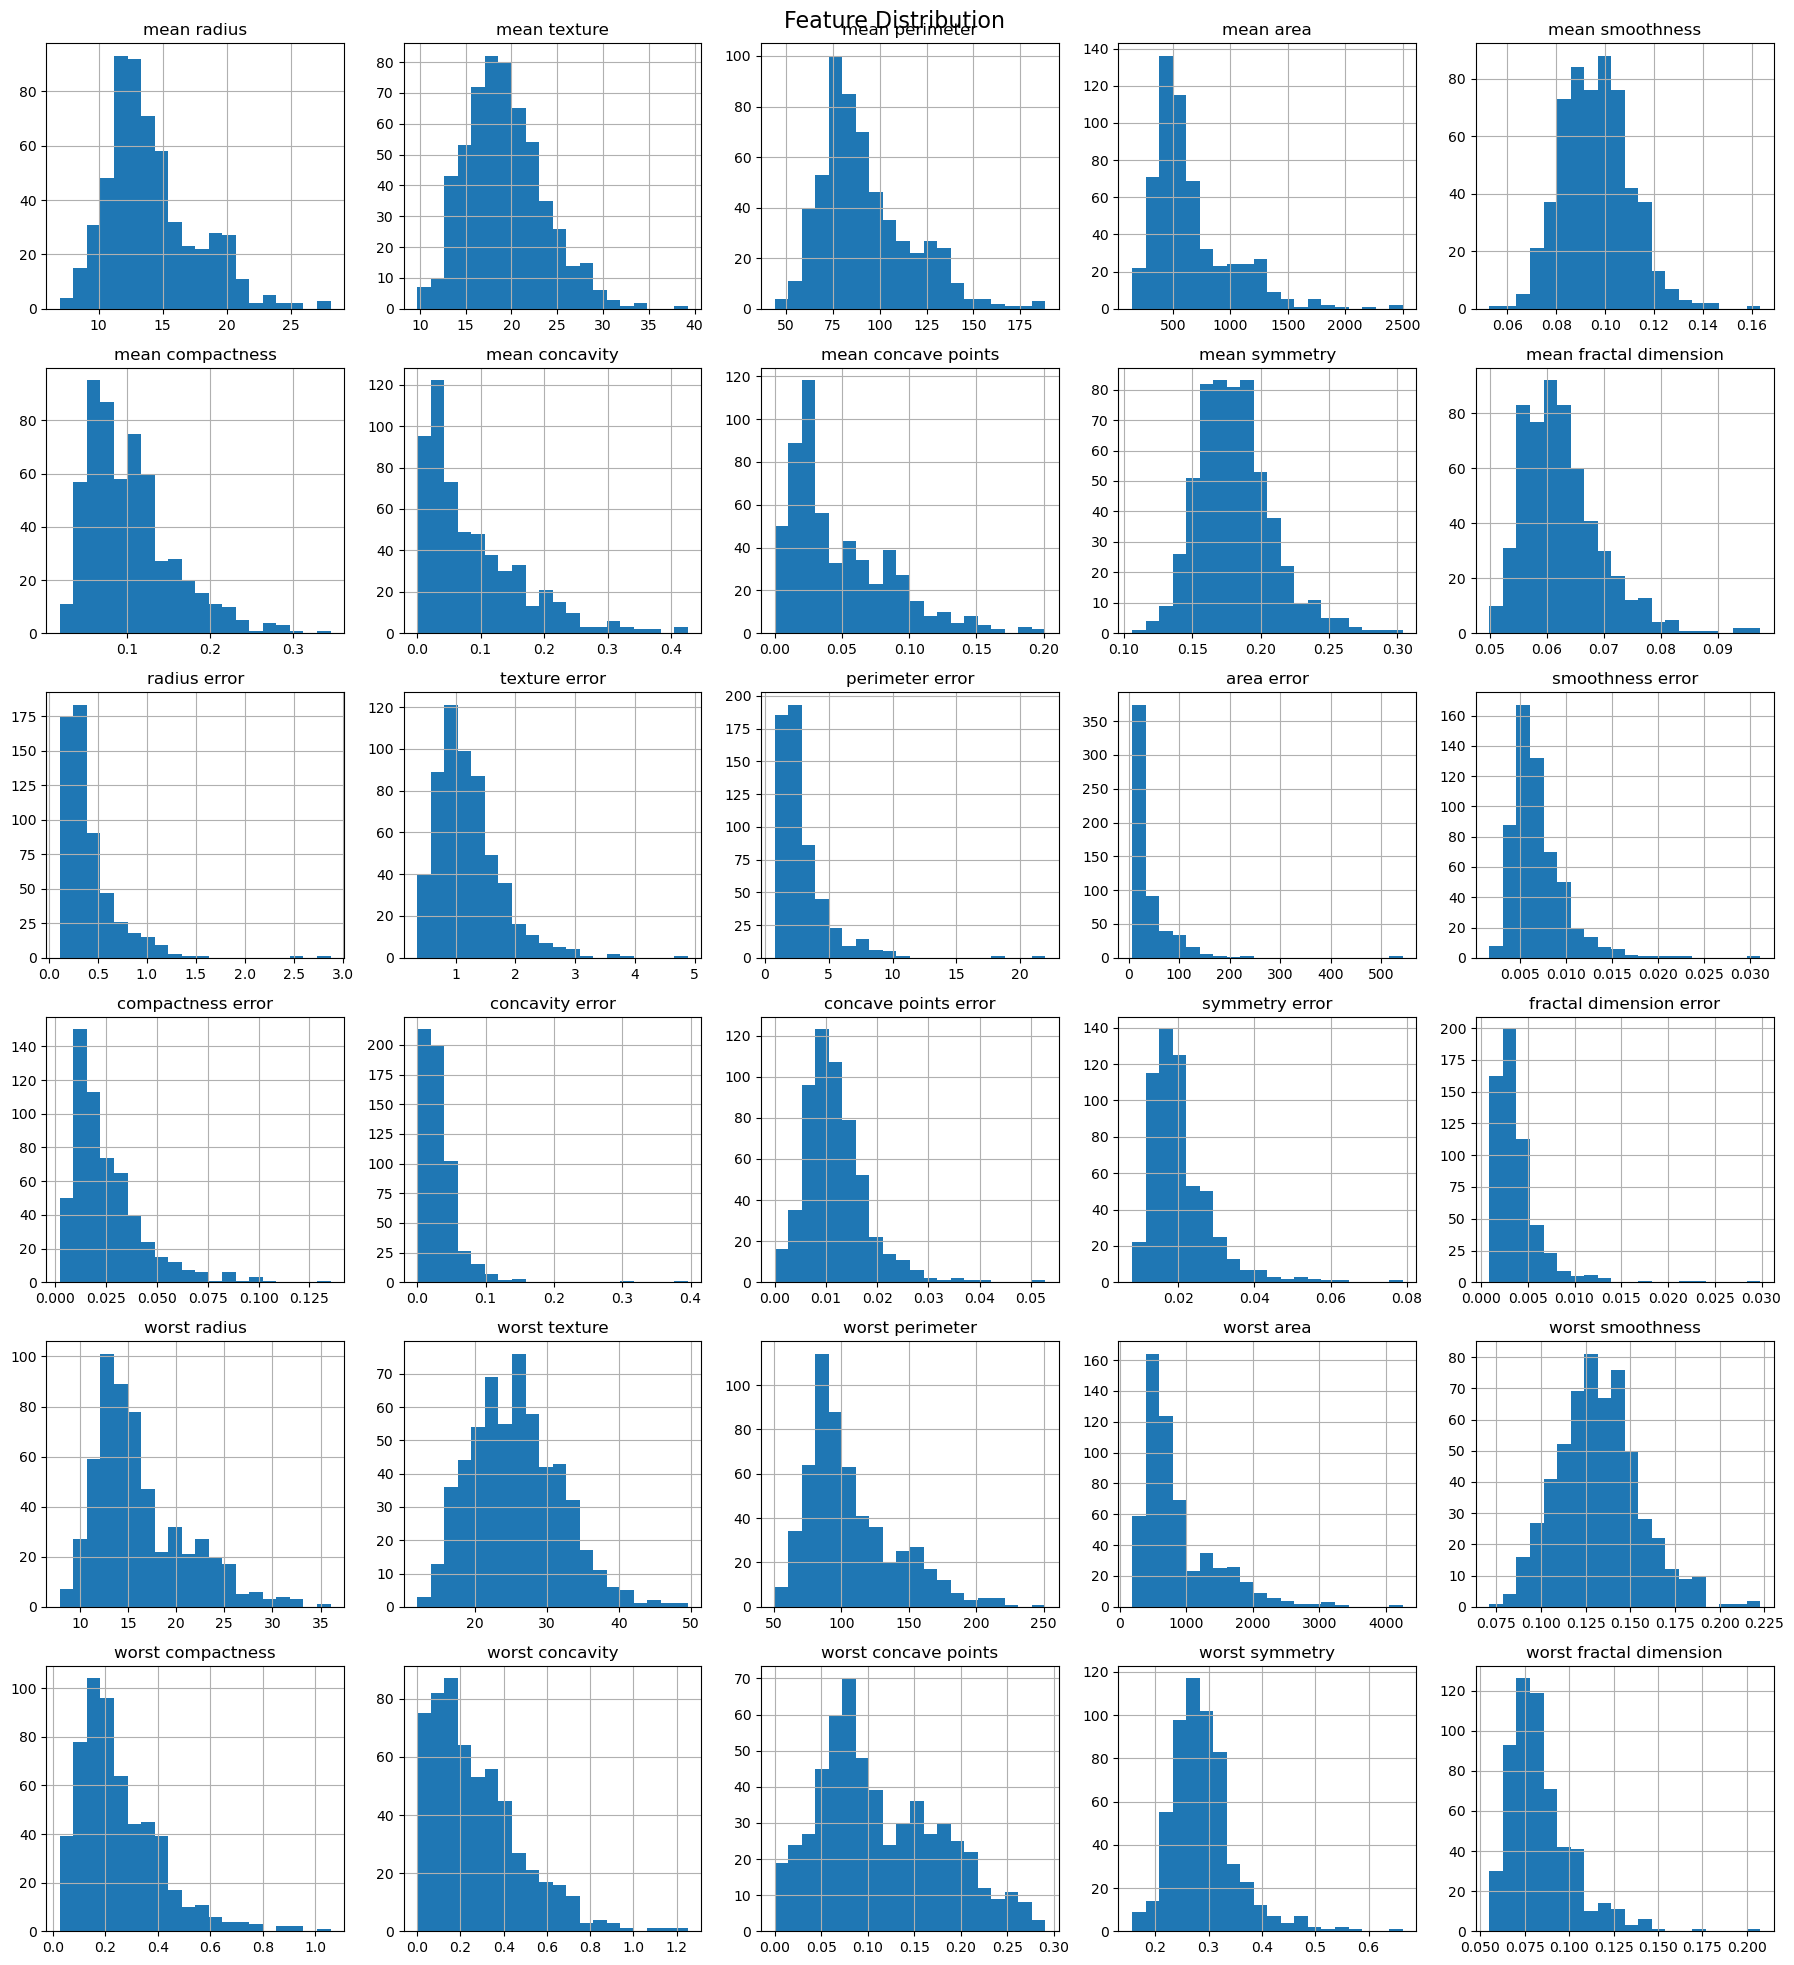

In [5]:
# Histograms for all features
df.drop("target", axis=1).hist(
    figsize=(18, 20),
    bins=20
)

plt.suptitle("Feature Distribution", fontsize=16)
plt.tight_layout()
plt.show()

### 4. Boxplots - Detect Outliers

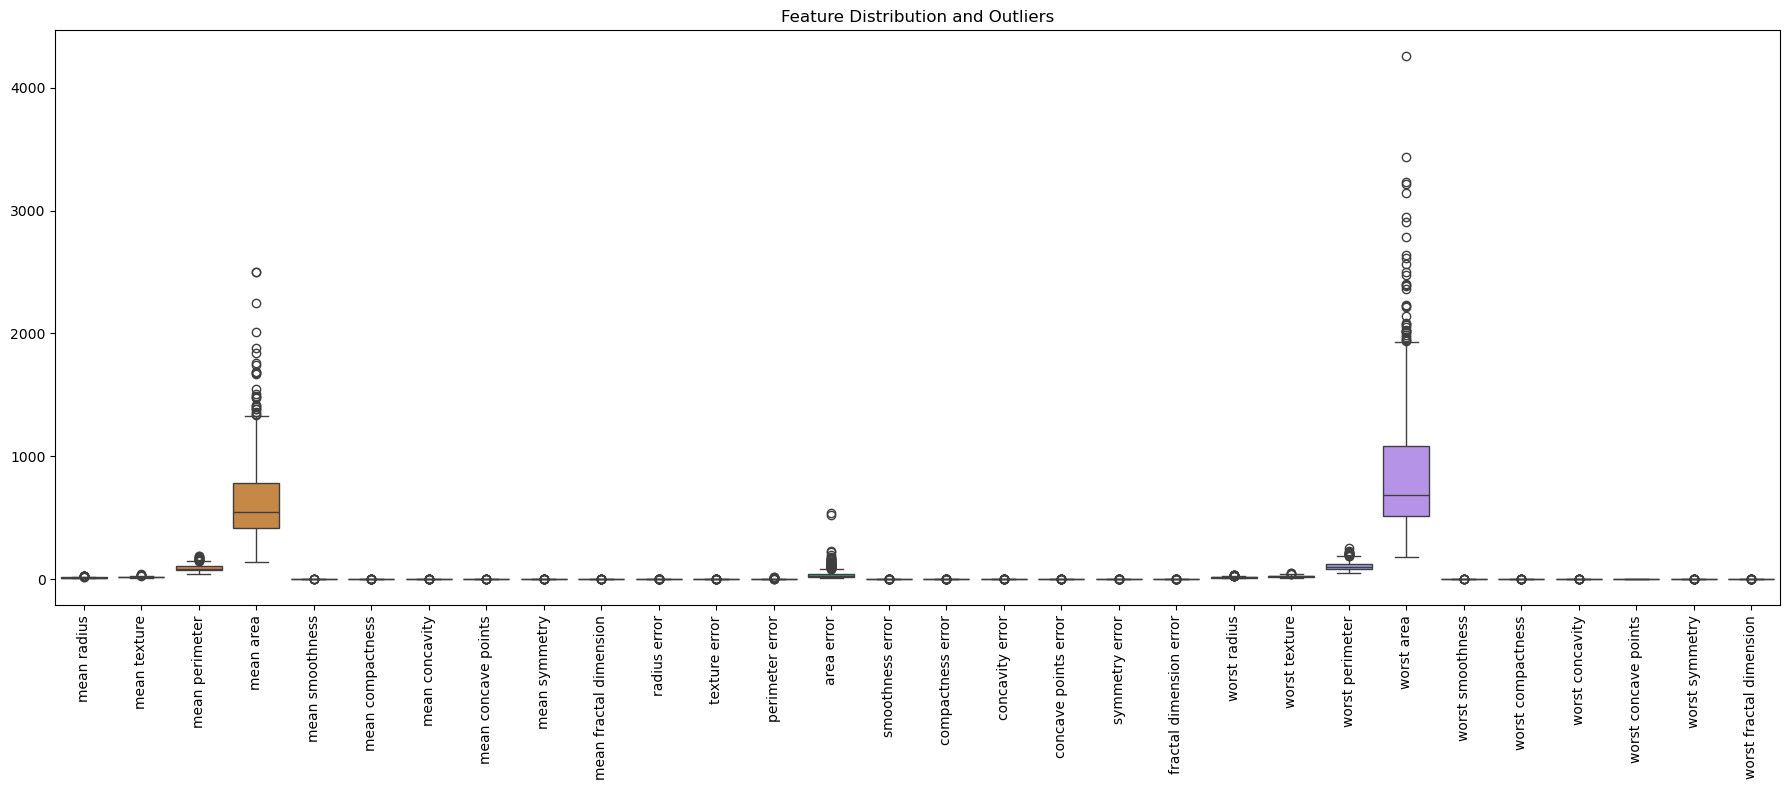

In [6]:
plt.figure(figsize=(18, 8))

sns.boxplot(data=X)

plt.xticks(rotation=90)
plt.title("Feature Distribution and Outliers")
plt.tight_layout()
plt.show()

### 5. Correlation Heatmap

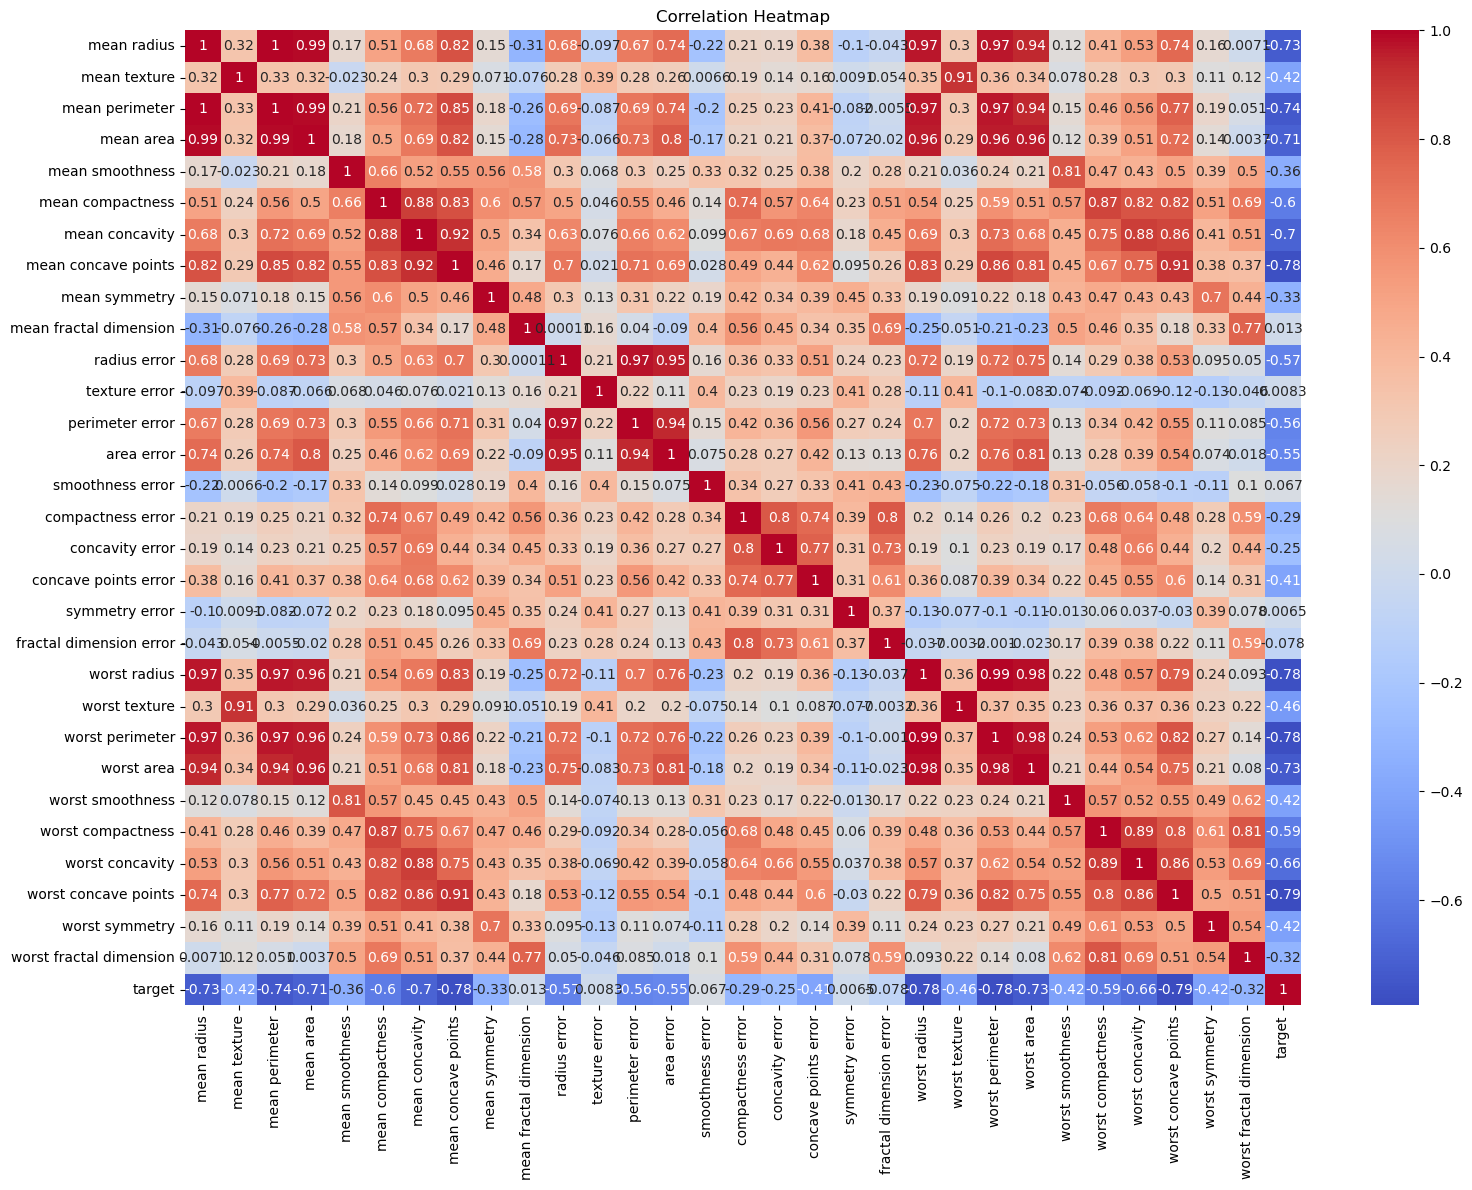

In [7]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 6. Split Dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)



Training Data: (455, 30)
Testing Data: (114, 30)


In [9]:
# 7. Feature Scaling

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 8. Logistic Regression Model

In [14]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
# 9. Prediction

In [17]:
y_pred = model.predict(X_test)

In [18]:
# 10. Model Evaluation

In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")

print("\nAccuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


LOGISTIC REGRESSION RESULTS

Accuracy: 0.9824561403508771

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



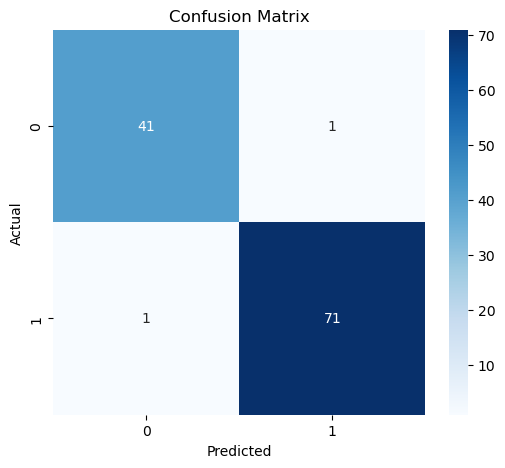

In [20]:

# 11. Confusion Matrix Visualization


plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()